<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [114]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import pandas as pd


dataset = load_iris()

X = dataset.data
y = dataset.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [115]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

dtc = DecisionTreeClassifier(max_depth= None,random_state=0)

dtc.fit(X_train, y_train)

prediction_treino = dtc.predict(X_train)
predictions_test = dtc.predict(X_test)

accuracy_treino = accuracy_score(y_train, prediction_treino)
accuracy_test = accuracy_score(y_test, predictions_test)

print("Accuracy Treino:", accuracy_treino)
print("Accuracy Test:", accuracy_test)


Accuracy Treino: 1.0
Accuracy Test: 0.9666666666666667


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

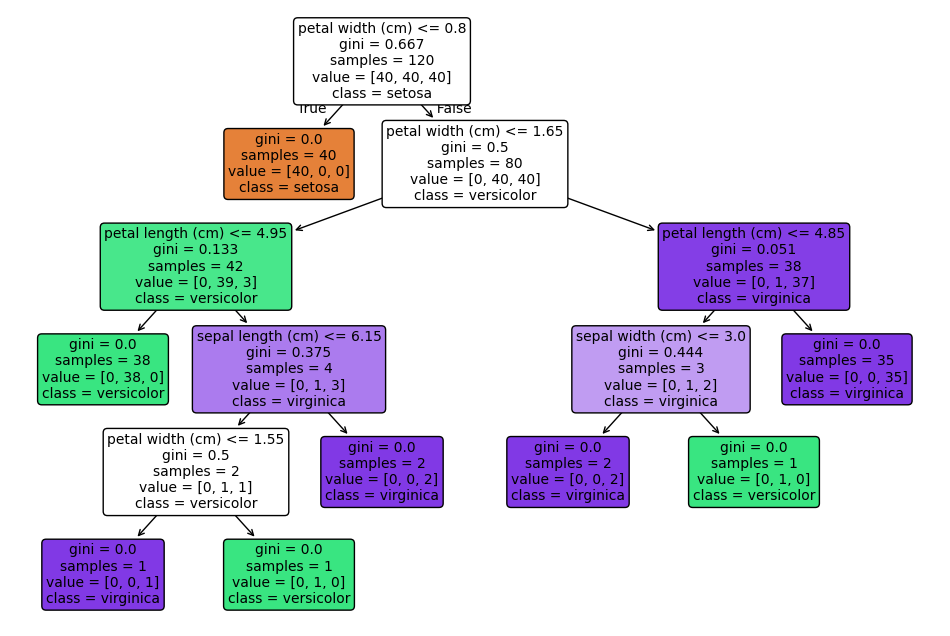

1- O atributo na raiz é petal width (cm)
2- A profundidade da árvore é 5


In [116]:
import matplotlib.pyplot as plt

feature_names = dataset.feature_names
class_names = dataset.target_names

plt.figure(figsize=(12, 8))
plot_tree(dtc, 
          feature_names=dataset.feature_names,
          class_names=dataset.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()

print("1- O atributo na raiz é", feature_names[dtc.tree_.feature[0]])
print("2- A profundidade da árvore é", dtc.get_depth())

**Adicione seu texto de solução aqui**.

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [122]:
for i in range (1,11):
    if i != 10:
        dtc = DecisionTreeClassifier(max_depth= i, random_state=0)
    else:
        dtc = DecisionTreeClassifier(max_depth= None, random_state=0)
        i= None
    
    dtc.fit(X_train, y_train)
    
    prediction_treino = dtc.predict(X_train)
    predictions_test = dtc.predict(X_test)
    
    accuracy_treino = accuracy_score(y_train, prediction_treino)
    accuracy_test = accuracy_score(y_test, predictions_test)
    
    print("Max Depth:", i)
    print("Accuracy Treino:", accuracy_treino)
    print("Accuracy Test:", accuracy_test)
    print("Profundidade da Árvore:", dtc.get_depth())
    print("Quantidade de folhas:", dtc.get_n_leaves())
    print("--------------------------------------------------")

Max Depth: 1
Accuracy Treino: 0.6666666666666666
Accuracy Test: 0.6666666666666666
Profundidade da Árvore: 1
Quantidade de folhas: 2
--------------------------------------------------
Max Depth: 2
Accuracy Treino: 0.9666666666666667
Accuracy Test: 0.9333333333333333
Profundidade da Árvore: 2
Quantidade de folhas: 3
--------------------------------------------------
Max Depth: 3
Accuracy Treino: 0.9833333333333333
Accuracy Test: 0.9666666666666667
Profundidade da Árvore: 3
Quantidade de folhas: 5
--------------------------------------------------
Max Depth: 4
Accuracy Treino: 0.9916666666666667
Accuracy Test: 0.9333333333333333
Profundidade da Árvore: 4
Quantidade de folhas: 7
--------------------------------------------------
Max Depth: 5
Accuracy Treino: 1.0
Accuracy Test: 0.9666666666666667
Profundidade da Árvore: 5
Quantidade de folhas: 8
--------------------------------------------------
Max Depth: 6
Accuracy Treino: 1.0
Accuracy Test: 0.9666666666666667
Profundidade da Árvore: 5
Q

**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

1- O overfitting começa quando a profundidade é = 4

2- A árvore consegue 100% no treino quando max_depth= None pois está com seus parâmetros especificamente treinados para atender os dados presentes no treino, provavelmente falhando quando novos dados forem introduzidos

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [118]:
depth = 3

dtc_gini = DecisionTreeClassifier(criterion='gini', max_depth= depth, random_state=0)
dtc_gini.fit(X_train, y_train)

prediction_treino_gini = dtc_gini.predict(X_train)
predictions_test_gini = dtc_gini.predict(X_test)

accuracy_treino_gini = accuracy_score(y_train, prediction_treino_gini)
accuracy_test_gini = accuracy_score(y_test, predictions_test_gini)

print("Criterion: Gini")
print("Accuracy Treino:", accuracy_treino_gini)
print("Accuracy Test:", accuracy_test_gini)
print("Profundidade da Árvore:", dtc_gini.get_depth())
print("---------------------------------------------------")

dtc_entropy = DecisionTreeClassifier(criterion='entropy', max_depth= depth, random_state=0)
dtc_entropy.fit(X_train, y_train)

prediction_treino_entropy = dtc_entropy.predict(X_train)
predictions_test_entropy = dtc_entropy.predict(X_test)

accuracy_treino_entropy = accuracy_score(y_train, prediction_treino_entropy)
accuracy_test_entropy = accuracy_score(y_test, predictions_test_entropy)

print("Criterion: Entropy")
print("Accuracy Treino:", accuracy_treino_entropy)
print("Accuracy Test:", accuracy_test_entropy)
print("Profundidade da Árvore:", dtc_entropy.get_depth())
print("---------------------------------------------------")

print("Diferença entre os critérios Gini e Entropy(test):", accuracy_test_gini/accuracy_test_entropy)
print("Diferença entre os critérios Gini e Entropy(treino):", accuracy_treino_gini/accuracy_treino_entropy)
print("Diferença entre os critérios Gini e Entropy(profundidade):", dtc_gini.get_depth()/dtc_entropy.get_depth())
print("\nPodemos ver que ambos os critérios apresentaram o mesmo resultado, independende da profundidade da árvore")

Criterion: Gini
Accuracy Treino: 0.9833333333333333
Accuracy Test: 0.9666666666666667
Profundidade da Árvore: 3
---------------------------------------------------
Criterion: Entropy
Accuracy Treino: 0.9833333333333333
Accuracy Test: 0.9666666666666667
Profundidade da Árvore: 3
---------------------------------------------------
Diferença entre os critérios Gini e Entropy(test): 1.0
Diferença entre os critérios Gini e Entropy(treino): 1.0
Diferença entre os critérios Gini e Entropy(profundidade): 1.0

Podemos ver que ambos os critérios apresentaram o mesmo resultado, independende da profundidade da árvore


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [119]:
dtc = DecisionTreeClassifier(max_depth= None, random_state=0, min_samples_leaf= 3)

dtc.fit(X_train, y_train)

prediction_treino = dtc.predict(X_train)
predictions_test = dtc.predict(X_test)

accuracy_treino = accuracy_score(y_train, prediction_treino)
accuracy_test = accuracy_score(y_test, predictions_test)

print("Accuracy Treino:", accuracy_treino)
print("Accuracy Test:", accuracy_test)
print("Profundidade da Árvore:", dtc.get_depth())
print("Quantidade de folhas:", dtc.get_n_leaves())

print("\nMelhor valor encontrado -> min_samples_leaf = 3")
print("O modelo se comportou comparavelmente ao modelo com max_depth = 3, previnindo overfitting")

Accuracy Treino: 0.9833333333333333
Accuracy Test: 0.9666666666666667
Profundidade da Árvore: 3
Quantidade de folhas: 5

Melhor valor encontrado -> min_samples_leaf = 3
O modelo se comportou comparavelmente ao modelo com max_depth = 3, previnindo overfitting
